# cw_odmr_lock_in result: scan1-scan6

Lock-in X/R vs. frequency for `scan1` through `scan6`, overlaid on one plot -- from `D:\cw_odmr_lock_in\scan{1..6}`. Superseded `average1` -- removed from this notebook, still on disk if needed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = r"D:\cw_odmr_lock_in"
RUN_NAMES = ["scan1", "scan2", "scan3", "scan4", "scan5", "scan6"]

runs = {}
for name in RUN_NAMES:
    run_path = f"{DATA_DIR}/{name}"
    freqs_hz = np.load(f"{run_path}/{name}_lockin_spectrum_freqs_hz.npy")
    x = np.load(f"{run_path}/{name}_lockin_spectrum_x.npy")
    y = np.load(f"{run_path}/{name}_lockin_spectrum_y.npy")
    reflected_dbm = np.load(f"{run_path}/{name}_lockin_spectrum_reflected_dbm.npy")
    freqs_ghz = freqs_hz / 1e9
    runs[name] = dict(freqs_ghz=freqs_ghz, x=x, y=y, r=np.hypot(x, y),
                       reflected_dbm=reflected_dbm)
    print(f"{name}: {len(freqs_hz)} points, "
          f"{freqs_ghz.min():.6f}-{freqs_ghz.max():.6f} GHz")

scan1: 137 points, 2.860250-2.873850 GHz
scan2: 130 points, 2.859750-2.872650 GHz


scan3: 133 points, 2.860725-2.873925 GHz
scan4: 116 points, 2.865825-2.877325 GHz


scan5: 136 points, 2.444725-2.458225 GHz
scan6: 129 points, 2.832600-2.845400 GHz


## Comparison: scan1 vs scan2 vs ... vs scan6

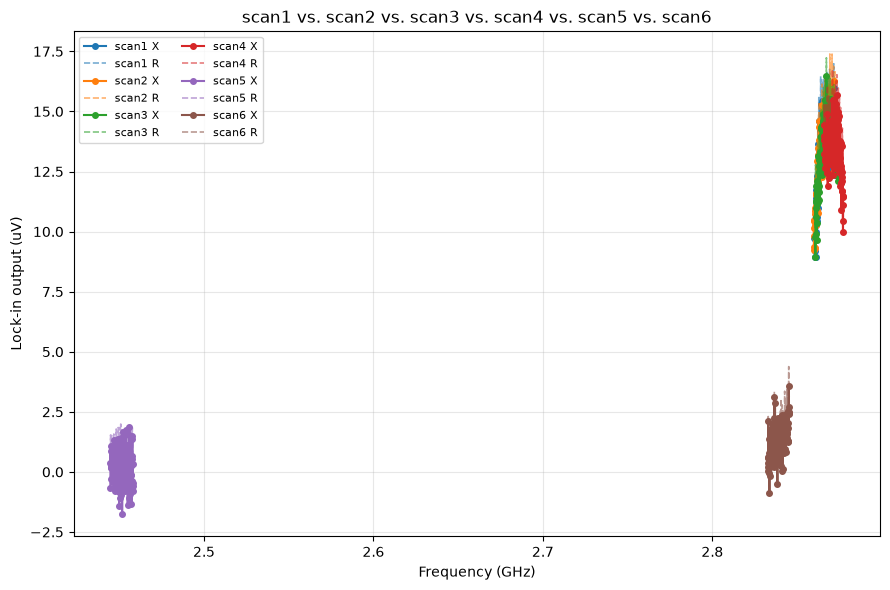

In [2]:
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors

for i, name in enumerate(RUN_NAMES):
    d = runs[name]
    color = colors[i % len(colors)]
    ax.plot(d["freqs_ghz"], d["x"] * 1e6, "o-", color=color, ms=4, label=f"{name} X")
    ax.plot(d["freqs_ghz"], d["r"] * 1e6, "--", color=color, lw=1.2, alpha=0.6, label=f"{name} R")

ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("Lock-in output (uV)")
ax.set_title(" vs. ".join(RUN_NAMES))
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()